In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# Load Data

In [2]:
Categories = pd.read_csv('categories.csv')
products = pd.read_csv('products.csv')
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
order_details = pd.read_csv(  "order_details.csv")

shape_summary = pd.DataFrame({
    'Table':['Categories','products','customers','orders','order_details'],
    'Rows':[len(Categories),len(products),len(customers),len(orders),len(order_details)],
    'cols':[Categories.shape[1],products.shape[1],customers.shape[1],orders.shape[1],order_details.shape[1]]
})
shape_summary

,Table,Rows,cols
0,Categories,10,2
1,products,100,3
2,customers,1000,7
3,orders,10000,4
4,order_details,30271,10


# Categories 

In [3]:
Categories.set_index('CategoryID' , inplace=True)
Categories

,CategoryName
CategoryID,
CTGRY0001,Meat & Poultry
CTGRY0002,Dairy & Eggs
CTGRY0003,Produce
CTGRY0004,Beverages
CTGRY0005,Bakery
CTGRY0006,Snacks
CTGRY0007,Pantry Staples
CTGRY0008,Personal Care
CTGRY0009,Household Cleaning


# Products

In [4]:
products.set_index('ProductID' , inplace=True)
products

,ProductName,CategoryID
ProductID,,
PRDCT0001,ABC's Beef Ribeye,CTGRY0001
PRDCT0002,XYZ's Chicken Breast,CTGRY0001
PRDCT0003,KLM's Turkey Breast,CTGRY0001
PRDCT0004,ABC's Lamb Chops,CTGRY0001
PRDCT0005,XYZ's Atlantic Salmon,CTGRY0001
...,...,...
PRDCT0096,JKL's Frozen Berries,CTGRY0010
PRDCT0097,GHI's Chicken Nuggets,CTGRY0010
PRDCT0098,JKL's Frozen Waffles,CTGRY0010


In [5]:
products.info()

<class 'pandas.DataFrame'>
Index: 100 entries, PRDCT0001 to PRDCT0100
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   ProductName  100 non-null    str  
 1   CategoryID   100 non-null    str  
dtypes: str(2)
memory usage: 2.3+ KB


In [6]:
products.isna().sum()

ProductName    0
CategoryID     0
dtype: int64

In [7]:
products.duplicated().sum()

np.int64(0)

In [8]:
products.describe(include='O')

C:\Users\Mokhtar\AppData\Local\Temp\ipykernel_13640\576453271.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  products.describe(include='O')


,ProductName,CategoryID
count,100,100
unique,100,10
top,ABC's Beef Ribeye,CTGRY0001
freq,1,10


In [9]:
join_df = products.merge(Categories, on='CategoryID')
join_df.groupby('CategoryName')['ProductName'].value_counts()

CategoryName  ProductName         
Bakery        PQR's Tortilla Wraps    1
              STU's Garlic Bread      1
              PQR's Cinnamon Rolls    1
              VWX's Pita Bread        1
              STU's Brioche Buns      1
                                     ..
Snacks        PQR's Protein Bar       1
              VWX's Popcorn           1
              PQR's Granola Bar       1
              STU's Tortilla Chips    1
              STU's Rice Cakes        1
Name: count, Length: 100, dtype: int64

# Customers

In [10]:
customers.set_index('CustomerID',inplace=True)
customers

,Gender,Age,City,Region,CustomerSegment,SignUpDate
CustomerID,,,,,,
CSTMR0001,Male,29,Istanbul,Marmara,Standard,2020-04-13
CSTMR0002,Other,40,Istanbul,Marmara,Standard,2020-04-08
CSTMR0003,Female,36,Bursa,Marmara,Premium,2022-08-14
CSTMR0004,Male,18,Istanbul,Marmara,Premium,2022-03-26
CSTMR0005,Male,43,Izmir,Aegean,Premium,2021-04-04
...,...,...,...,...,...,...
CSTMR0996,Female,49,Aydin,Aegean,Standard,2023-01-06
CSTMR0997,Female,36,Izmir,Aegean,Premium,2023-04-09
CSTMR0998,Male,24,Istanbul,Marmara,Standard,2022-10-12


In [11]:
customers.info()

<class 'pandas.DataFrame'>
Index: 1000 entries, CSTMR0001 to CSTMR1000
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Gender           1000 non-null   str  
 1   Age              1000 non-null   int64
 2   City             1000 non-null   str  
 3   Region           1000 non-null   str  
 4   CustomerSegment  1000 non-null   str  
 5   SignUpDate       1000 non-null   str  
dtypes: int64(1), str(5)
memory usage: 54.7+ KB


In [12]:
customers.isna().sum()

Gender             0
Age                0
City               0
Region             0
CustomerSegment    0
SignUpDate         0
dtype: int64

In [13]:
customers.duplicated().sum()

np.int64(0)

In [14]:
customers.describe(include='O')

C:\Users\Mokhtar\AppData\Local\Temp\ipykernel_13640\1773320255.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  customers.describe(include='O')


,Gender,City,Region,CustomerSegment,SignUpDate
count,1000,1000,1000,1000,1000
unique,3,10,5,3,666
top,Male,Istanbul,Marmara,Standard,2021-04-04
freq,489,364,566,598,4


In [15]:
customers['Gender'].unique()

<StringArray>
['Male', 'Other', 'Female']
Length: 3, dtype: str

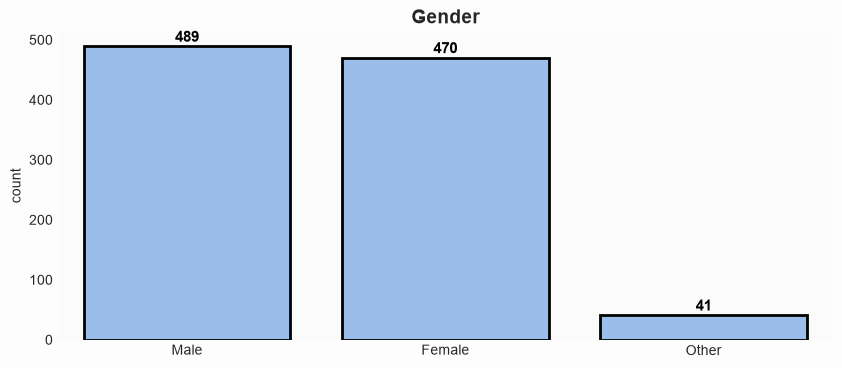

In [16]:
plt.style.use('seaborn-v0_8-dark')
fig , ax = plt.subplots(figsize=(10,4))
order = customers['Gender'].value_counts().index
x = sns.countplot(data=customers,x='Gender',order=order,color="#8DBCF6",linewidth=2,edgecolor='black')
for count in x.containers:
    x.bar_label(count,fmt='%.0f',padding=1,color='black',fontsize=11,fontweight='bold')
ax.set_title('Gender',fontsize=14,fontweight="bold")
ax.set_xlabel('')
ax.set_facecolor("#FBFBFB")
fig.patch.set_facecolor("#FDFDFD")
plt.show()

### Insight
The customer base is relatively balanced between male and
female customers.

In [17]:
customers['CustomerSegment'].unique()

<StringArray>
['Standard', 'Premium', 'VIP']
Length: 3, dtype: str

In [18]:
customers['CustomerSegment'].value_counts()


CustomerSegment
Standard    598
Premium     308
VIP          94
Name: count, dtype: int64

In [19]:
customers['Region'].unique()

<StringArray>
['Marmara', 'Aegean', 'Mediterranean', 'Central Anatolia', 'Black Sea']
Length: 5, dtype: str

In [20]:
customers['City'].unique()


<StringArray>
[ 'Istanbul',     'Bursa',     'Izmir',   'Antalya',    'Ankara',   'Trabzon',
 'Eskisehir',     'Adana',   'Kocaeli',     'Aydin']
Length: 10, dtype: str

In [21]:
customers.groupby('Region')['City'].unique()

Region
Aegean                          [Izmir, Aydin]
Black Sea                            [Trabzon]
Central Anatolia           [Ankara, Eskisehir]
Marmara             [Istanbul, Bursa, Kocaeli]
Mediterranean                 [Antalya, Adana]
Name: City, dtype: object

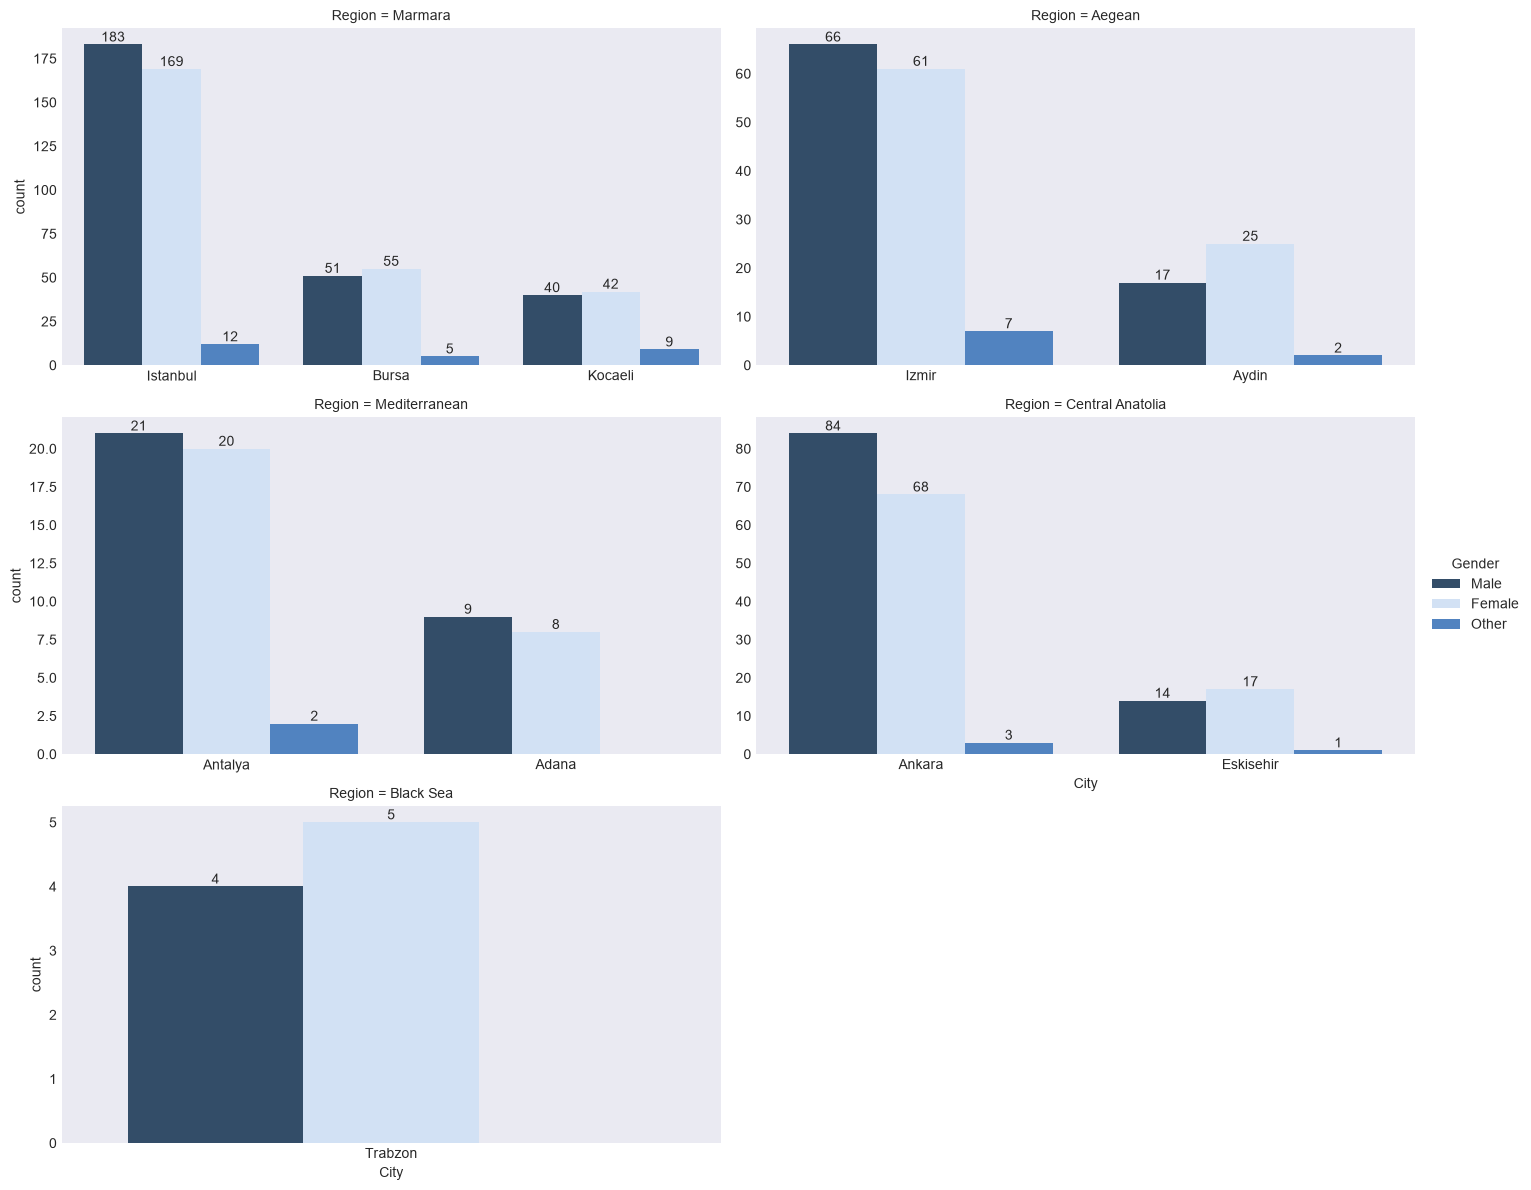

In [22]:
gender_order = customers['Gender'].value_counts().index
ax =sns.catplot(data=customers,x='City',hue='Gender',col='Region',kind='count',hue_order=gender_order,palette=["#2A4D71", "#CCE1FA","#3E81D3"],col_wrap=2,height=4,aspect=1.8,sharex=False,sharey=False)
for x in ax.axes.flat:
    for count_bar in x.containers:
        x.bar_label(count_bar)
plt.show()

In [23]:
customers['CustomerSegment'].value_counts()

CustomerSegment
Standard    598
Premium     308
VIP          94
Name: count, dtype: int64

# Orders

In [24]:
orders.set_index('OrderID',inplace=True)
orders

,CustomerID,OrderDate,OrderTime
OrderID,,,
ORD00001,CSTMR0983,2021-04-10,12:53:24
ORD00002,CSTMR0703,2024-04-21,22:08:16
ORD00003,CSTMR0920,2022-10-27,10:21:26
ORD00004,CSTMR0158,2025-11-07,22:24:27
ORD00005,CSTMR0834,2021-09-05,13:23:16
...,...,...,...
ORD09996,CSTMR0647,2023-12-10,10:12:24
ORD09997,CSTMR0180,2025-06-07,21:52:25
ORD09998,CSTMR0351,2026-04-03,18:09:57


In [25]:
orders.info()

<class 'pandas.DataFrame'>
Index: 10000 entries, ORD00001 to ORD10000
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   CustomerID  10000 non-null  str  
 1   OrderDate   10000 non-null  str  
 2   OrderTime   10000 non-null  str  
dtypes: str(3)
memory usage: 312.5+ KB


In [26]:
orders.isna().sum()

CustomerID    0
OrderDate     0
OrderTime     0
dtype: int64

In [27]:
orders.duplicated().sum()

np.int64(0)

In [28]:
orders['OrderDate']=pd.to_datetime(orders['OrderDate'])

In [29]:
orders['Years'] = orders['OrderDate'].dt.year
orders['Months'] = orders['OrderDate'].dt.month_name()
orders

,CustomerID,OrderDate,OrderTime,Years,Months
OrderID,,,,,
ORD00001,CSTMR0983,2021-04-10,12:53:24,2021,April
ORD00002,CSTMR0703,2024-04-21,22:08:16,2024,April
ORD00003,CSTMR0920,2022-10-27,10:21:26,2022,October
ORD00004,CSTMR0158,2025-11-07,22:24:27,2025,November
ORD00005,CSTMR0834,2021-09-05,13:23:16,2021,September
...,...,...,...,...,...
ORD09996,CSTMR0647,2023-12-10,10:12:24,2023,December
ORD09997,CSTMR0180,2025-06-07,21:52:25,2025,June
ORD09998,CSTMR0351,2026-04-03,18:09:57,2026,April


In [30]:
orders['Years'].unique()

array([2021, 2024, 2022, 2025, 2026, 2023], dtype=int32)

In [31]:
orders['Years'].value_counts()


Years
2025    2247
2023    2244
2024    2235
2022    1511
2026     926
2021     837
Name: count, dtype: int64

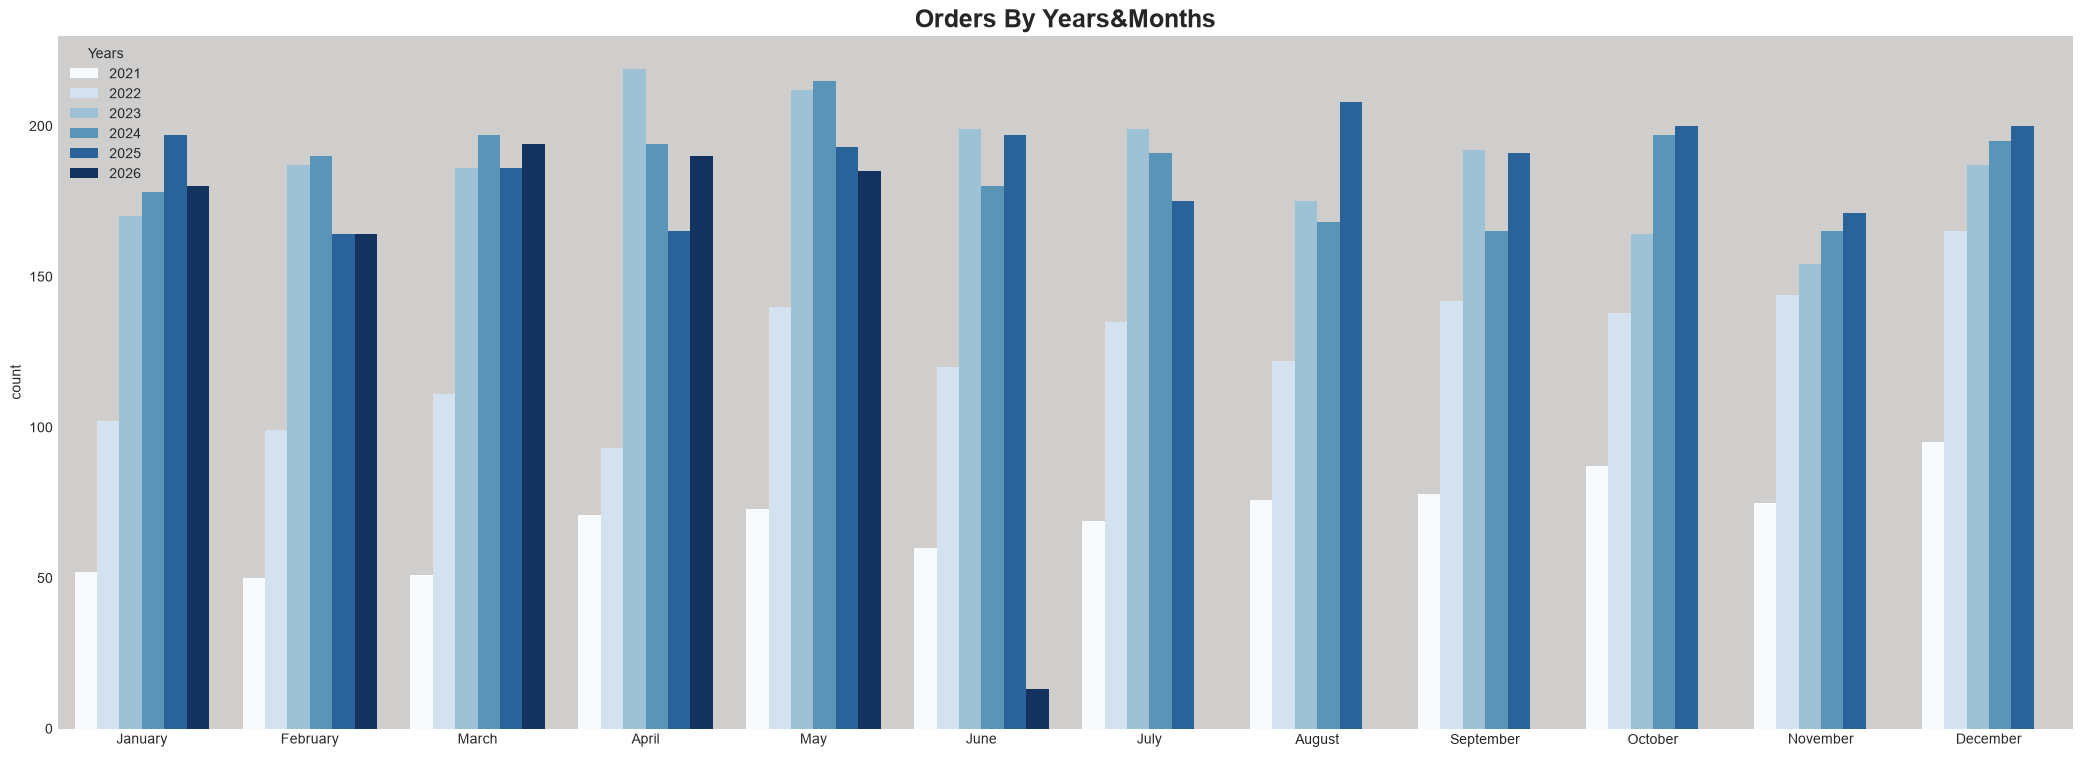

In [32]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]
year_order  = orders['Years'].value_counts().index
fig,ax = plt.subplots(figsize= (26,9))
sns.countplot(data=orders , x= 'Months',order=month_order, hue= 'Years',hue_order = year_order ,palette='Blues')
ax.set_title('Orders By Years&Months',fontsize = 18,fontweight = 'bold')
ax.set_xlabel('')
ax.set_facecolor("#B0ABAB96")

# Details_Orders

In [33]:
order_details.set_index('OrderID',inplace=True)
order_details

,ProductID,Quantity,UnitCost,UnitPrice,DiscountRate,IsReturned,ReturnDate,ReturnTime,ReturnReason
OrderID,,,,,,,,,
ORD00001,PRDCT0056,3,2.14,3.38,0.00,0,9999-12-31,00:00:00,NaN
ORD00002,PRDCT0028,2,4.17,5.31,0.00,0,9999-12-31,00:00:00,NaN
ORD00002,PRDCT0001,13,20.36,25.77,0.05,0,9999-12-31,00:00:00,NaN
ORD00003,PRDCT0030,2,0.90,1.35,0.00,0,9999-12-31,00:00:00,NaN
ORD00004,PRDCT0003,3,12.84,20.35,0.00,0,9999-12-31,00:00:00,NaN
...,...,...,...,...,...,...,...,...,...
ORD09999,PRDCT0049,2,3.73,5.44,0.00,0,9999-12-31,00:00:00,NaN
ORD09999,PRDCT0052,3,3.30,4.71,0.00,0,9999-12-31,00:00:00,NaN
ORD09999,PRDCT0033,3,2.87,4.06,0.00,0,9999-12-31,00:00:00,NaN


In [34]:
order_details.info()

<class 'pandas.DataFrame'>
Index: 30271 entries, ORD00001 to ORD10000
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ProductID     30271 non-null  str    
 1   Quantity      30271 non-null  int64  
 2   UnitCost      30271 non-null  float64
 3   UnitPrice     30271 non-null  float64
 4   DiscountRate  30271 non-null  float64
 5   IsReturned    30271 non-null  int64  
 6   ReturnDate    30271 non-null  str    
 7   ReturnTime    30271 non-null  str    
 8   ReturnReason  1424 non-null   str    
dtypes: float64(3), int64(2), str(4)
memory usage: 2.3+ MB


In [35]:
order_details.duplicated().sum()

np.int64(19827)

In [36]:
order_details.isna().sum()

ProductID           0
Quantity            0
UnitCost            0
UnitPrice           0
DiscountRate        0
IsReturned          0
ReturnDate          0
ReturnTime          0
ReturnReason    28847
dtype: int64

In [37]:
order_details.describe()

,Quantity,UnitCost,UnitPrice,DiscountRate,IsReturned
count,30271.000000,30271.000000,30271.000000,30271.000000,30271.000000
mean,2.681312,6.803363,9.793923,0.037059,0.047042
std,3.269558,5.554954,7.958749,0.074929,0.211732
min,1.000000,0.820000,1.170000,0.000000,0.000000
25%,1.000000,3.040000,4.500000,0.000000,0.000000
50%,2.000000,5.140000,7.440000,0.000000,0.000000
75%,3.000000,8.940000,12.680000,0.050000,0.000000
max,25.000000,32.810000,49.620000,0.400000,1.000000


In [38]:
order_details.describe(include='O')

C:\Users\Mokhtar\AppData\Local\Temp\ipykernel_13640\2573167200.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  order_details.describe(include='O')


,ProductID,ReturnDate,ReturnTime,ReturnReason
count,30271,30271,30271,1424
unique,100,986,1408,29
top,PRDCT0030,9999-12-31,00:00:00,Customer Changed Mind
freq,440,28847,28847,299


In [39]:
# TotalSales represents sales after applying the discount
order_details['TotalCost'] = order_details['Quantity'] * order_details['UnitCost']
order_details['TotalSales'] = order_details['Quantity'] * order_details['UnitPrice'] * (1-order_details['DiscountRate'])
order_details['NetCost'] = order_details['TotalCost'].where(order_details['IsReturned'] == 0,0)
order_details['NetSales'] = order_details['TotalSales'].where(order_details['IsReturned'] == 0,0)
order_details['Profit'] = order_details['NetSales'] - order_details['NetCost']

order_details

,ProductID,Quantity,UnitCost,UnitPrice,DiscountRate,IsReturned,ReturnDate,ReturnTime,ReturnReason,TotalCost,TotalSales,NetCost,NetSales,Profit
OrderID,,,,,,,,,,,,,,
ORD00001,PRDCT0056,3,2.14,3.38,0.00,0,9999-12-31,00:00:00,NaN,6.42,10.1400,6.42,10.1400,3.7200
ORD00002,PRDCT0028,2,4.17,5.31,0.00,0,9999-12-31,00:00:00,NaN,8.34,10.6200,8.34,10.6200,2.2800
ORD00002,PRDCT0001,13,20.36,25.77,0.05,0,9999-12-31,00:00:00,NaN,264.68,318.2595,264.68,318.2595,53.5795
ORD00003,PRDCT0030,2,0.90,1.35,0.00,0,9999-12-31,00:00:00,NaN,1.80,2.7000,1.80,2.7000,0.9000
ORD00004,PRDCT0003,3,12.84,20.35,0.00,0,9999-12-31,00:00:00,NaN,38.52,61.0500,38.52,61.0500,22.5300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ORD09999,PRDCT0049,2,3.73,5.44,0.00,0,9999-12-31,00:00:00,NaN,7.46,10.8800,7.46,10.8800,3.4200
ORD09999,PRDCT0052,3,3.30,4.71,0.00,0,9999-12-31,00:00:00,NaN,9.90,14.1300,9.90,14.1300,4.2300
ORD09999,PRDCT0033,3,2.87,4.06,0.00,0,9999-12-31,00:00:00,NaN,8.61,12.1800,8.61,12.1800,3.5700


In [40]:
order_details=order_details.join(orders[['OrderDate']],how='left')


In [41]:
order_details['Years'] = order_details['OrderDate'].dt.year
order_details['Months'] = order_details['OrderDate'].dt.month_name()

In [42]:
order_details.drop(columns='OrderDate',inplace=True)

In [43]:
order_details

,ProductID,Quantity,UnitCost,UnitPrice,DiscountRate,IsReturned,ReturnDate,ReturnTime,ReturnReason,TotalCost,TotalSales,NetCost,NetSales,Profit,Years,Months
OrderID,,,,,,,,,,,,,,,,
ORD00001,PRDCT0056,3,2.14,3.38,0.00,0,9999-12-31,00:00:00,NaN,6.42,10.1400,6.42,10.1400,3.7200,2021,April
ORD00002,PRDCT0028,2,4.17,5.31,0.00,0,9999-12-31,00:00:00,NaN,8.34,10.6200,8.34,10.6200,2.2800,2024,April
ORD00002,PRDCT0001,13,20.36,25.77,0.05,0,9999-12-31,00:00:00,NaN,264.68,318.2595,264.68,318.2595,53.5795,2024,April
ORD00003,PRDCT0030,2,0.90,1.35,0.00,0,9999-12-31,00:00:00,NaN,1.80,2.7000,1.80,2.7000,0.9000,2022,October
ORD00004,PRDCT0003,3,12.84,20.35,0.00,0,9999-12-31,00:00:00,NaN,38.52,61.0500,38.52,61.0500,22.5300,2025,November
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ORD09999,PRDCT0049,2,3.73,5.44,0.00,0,9999-12-31,00:00:00,NaN,7.46,10.8800,7.46,10.8800,3.4200,2024,November
ORD09999,PRDCT0052,3,3.30,4.71,0.00,0,9999-12-31,00:00:00,NaN,9.90,14.1300,9.90,14.1300,4.2300,2024,November
ORD09999,PRDCT0033,3,2.87,4.06,0.00,0,9999-12-31,00:00:00,NaN,8.61,12.1800,8.61,12.1800,3.5700,2024,November


In [44]:
order_details['TotalCost'].agg(['sum','max','min'])

sum    550322.59
max       721.82
min         0.82
Name: TotalCost, dtype: float64

In [45]:

order_details['TotalSales'].agg(['sum','max','min'])


sum    761951.1295
max      1082.6400
min         0.9450
Name: TotalSales, dtype: float64

In [46]:
order_details['NetCost'].agg(['sum','max','min'])


sum    526268.75
max       721.82
min         0.00
Name: NetCost, dtype: float64

In [47]:
order_details['NetSales'].agg(['sum','max','min'])


sum    728473.119
max      1082.640
min         0.000
Name: NetSales, dtype: float64

In [48]:
print(order_details['Profit'].agg('sum'))

202204.369


In [49]:
yearly_profit = order_details.groupby('Years')[['TotalCost', 'TotalSales', 'NetCost', 'NetSales', 'Profit']].sum()
yearly_profit

,TotalCost,TotalSales,NetCost,NetSales,Profit
Years,,,,,
2021,36423.09,50524.8815,35025.98,48581.0480,13555.0680
2022,70103.18,96827.7425,67582.73,93326.0505,25743.3205
2023,113824.70,157163.2910,107389.29,148393.7105,41004.4205
2024,131352.22,181104.1535,126101.23,173723.6795,47622.4495
2025,133526.57,184459.3020,127720.36,176310.3740,48590.0140
2026,65092.83,91871.7590,62449.16,88138.2565,25689.0965


In [50]:
Profit_Table = order_details.pivot_table(index=['Years','Months'] , values=['TotalCost','TotalSales','NetCost','NetSales','Profit'],aggfunc='sum')
Profit_Table

NetCost    NetSales     Profit  TotalCost  TotalSales
Years Months                                                          
2021  April      3464.30   4928.6800  1464.3800    3538.47   5035.8940
      August     3512.37   4991.1325  1478.7625    3587.99   5099.5005
      December   3031.30   4207.4530  1176.1530    3121.01   4334.3105
      February   3302.57   4461.0815  1158.5115    3375.97   4550.3430
      January    2415.26   3385.0535   969.7935    2553.13   3572.6835
...                  ...         ...        ...        ...         ...
2026  February   8754.63  11838.9230  3084.2930    8934.90  12088.9650
      January   12474.47  17626.2285  5151.7585   12935.75  18266.4980
      June        805.98   1136.7365   330.7565     823.46   1161.0280
      March     13667.18  19599.2290  5932.0490   14182.68  20332.9865
      May       14009.49  19794.2420  5784.7520   14953.55  21118.4400

[66 rows x 5 columns]

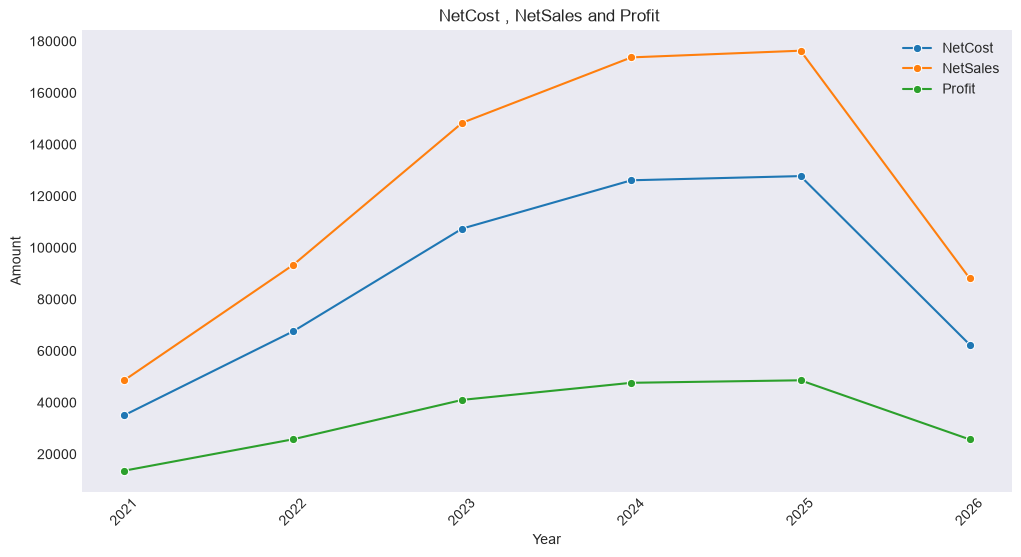

In [51]:
plt.figure(figsize=(12, 6))

sns.lineplot(data=yearly_profit, x='Years', y='NetCost',label='NetCost',marker='o')
sns.lineplot(data=yearly_profit, x='Years', y='NetSales',label='NetSales',marker='o')
sns.lineplot(data=yearly_profit, x='Years', y='Profit',label='Profit',marker='o')

plt.title(' NetCost , NetSales and Profit')
plt.xlabel('Year')
plt.ylabel('Amount')

plt.xticks(rotation=45)
plt.show()

In [52]:
# IsReturned
IsReturned = order_details[order_details['IsReturned'] == 1]
IsReturned

,ProductID,Quantity,UnitCost,UnitPrice,DiscountRate,IsReturned,ReturnDate,ReturnTime,ReturnReason,TotalCost,TotalSales,NetCost,NetSales,Profit,Years,Months
OrderID,,,,,,,,,,,,,,,,
ORD00012,PRDCT0029,18,1.35,2.11,0.00,1,2025-06-09,22:56:54,Molded/Rotten,24.30,37.980,0.0,0.0,0.0,2025,June
ORD00013,PRDCT0016,2,5.80,9.15,0.10,1,2025-06-08,08:11:28,Expired Date,11.60,16.470,0.0,0.0,0.0,2025,June
ORD00018,PRDCT0037,1,1.42,1.85,0.00,1,2023-03-20,09:21:35,Damaged Can,1.42,1.850,0.0,0.0,0.0,2023,March
ORD00022,PRDCT0016,3,4.79,7.56,0.15,1,2023-09-13,00:24:01,Wrong Item Sent,14.37,19.278,0.0,0.0,0.0,2023,September
ORD00024,PRDCT0006,1,11.10,13.99,0.00,1,2024-08-24,11:52:38,Spoiled/Expired,11.10,13.990,0.0,0.0,0.0,2024,August
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ORD09958,PRDCT0037,1,1.42,1.85,0.00,1,2023-05-27,12:42:47,Expired Date,1.42,1.850,0.0,0.0,0.0,2023,May
ORD09964,PRDCT0018,2,8.07,10.60,0.00,1,2023-07-01,05:28:41,Wrong Item Sent,16.14,21.200,0.0,0.0,0.0,2023,June
ORD09964,PRDCT0028,3,3.79,4.83,0.00,1,2023-06-30,11:28:41,Unripe Product,11.37,14.490,0.0,0.0,0.0,2023,June


In [53]:
IsReturned.info()

<class 'pandas.DataFrame'>
Index: 1424 entries, ORD00012 to ORD09990
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ProductID     1424 non-null   str    
 1   Quantity      1424 non-null   int64  
 2   UnitCost      1424 non-null   float64
 3   UnitPrice     1424 non-null   float64
 4   DiscountRate  1424 non-null   float64
 5   IsReturned    1424 non-null   int64  
 6   ReturnDate    1424 non-null   str    
 7   ReturnTime    1424 non-null   str    
 8   ReturnReason  1424 non-null   str    
 9   TotalCost     1424 non-null   float64
 10  TotalSales    1424 non-null   float64
 11  NetCost       1424 non-null   float64
 12  NetSales      1424 non-null   float64
 13  Profit        1424 non-null   float64
 14  Years         1424 non-null   int32  
 15  Months        1424 non-null   str    
dtypes: float64(8), int32(1), int64(2), str(5)
memory usage: 183.6+ KB


In [54]:
# Years & Months
IsReturned['ReturnDate'] = pd.to_datetime(IsReturned['ReturnDate'])

In [55]:
IsReturned['Years'] = IsReturned['ReturnDate'].dt.year
IsReturned['Months'] = IsReturned['ReturnDate'].dt.month_name()
IsReturned

,ProductID,Quantity,UnitCost,UnitPrice,DiscountRate,IsReturned,ReturnDate,ReturnTime,ReturnReason,TotalCost,TotalSales,NetCost,NetSales,Profit,Years,Months
OrderID,,,,,,,,,,,,,,,,
ORD00012,PRDCT0029,18,1.35,2.11,0.00,1,2025-06-09,22:56:54,Molded/Rotten,24.30,37.980,0.0,0.0,0.0,2025,June
ORD00013,PRDCT0016,2,5.80,9.15,0.10,1,2025-06-08,08:11:28,Expired Date,11.60,16.470,0.0,0.0,0.0,2025,June
ORD00018,PRDCT0037,1,1.42,1.85,0.00,1,2023-03-20,09:21:35,Damaged Can,1.42,1.850,0.0,0.0,0.0,2023,March
ORD00022,PRDCT0016,3,4.79,7.56,0.15,1,2023-09-13,00:24:01,Wrong Item Sent,14.37,19.278,0.0,0.0,0.0,2023,September
ORD00024,PRDCT0006,1,11.10,13.99,0.00,1,2024-08-24,11:52:38,Spoiled/Expired,11.10,13.990,0.0,0.0,0.0,2024,August
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ORD09958,PRDCT0037,1,1.42,1.85,0.00,1,2023-05-27,12:42:47,Expired Date,1.42,1.850,0.0,0.0,0.0,2023,May
ORD09964,PRDCT0018,2,8.07,10.60,0.00,1,2023-07-01,05:28:41,Wrong Item Sent,16.14,21.200,0.0,0.0,0.0,2023,July
ORD09964,PRDCT0028,3,3.79,4.83,0.00,1,2023-06-30,11:28:41,Unripe Product,11.37,14.490,0.0,0.0,0.0,2023,June


In [56]:
# ReturnDay
IsReturned = IsReturned.join(orders[['OrderDate']],how='left')
IsReturned['ReturnDay'] = IsReturned['ReturnDate'] - IsReturned['OrderDate']

In [57]:
IsReturned.drop(columns='OrderDate',inplace=True)

In [58]:
IsReturned

,ProductID,Quantity,UnitCost,UnitPrice,DiscountRate,IsReturned,ReturnDate,ReturnTime,ReturnReason,TotalCost,TotalSales,NetCost,NetSales,Profit,Years,Months,ReturnDay
OrderID,,,,,,,,,,,,,,,,,
ORD00012,PRDCT0029,18,1.35,2.11,0.00,1,2025-06-09,22:56:54,Molded/Rotten,24.30,37.980,0.0,0.0,0.0,2025,June,2 days
ORD00013,PRDCT0016,2,5.80,9.15,0.10,1,2025-06-08,08:11:28,Expired Date,11.60,16.470,0.0,0.0,0.0,2025,June,3 days
ORD00018,PRDCT0037,1,1.42,1.85,0.00,1,2023-03-20,09:21:35,Damaged Can,1.42,1.850,0.0,0.0,0.0,2023,March,3 days
ORD00022,PRDCT0016,3,4.79,7.56,0.15,1,2023-09-13,00:24:01,Wrong Item Sent,14.37,19.278,0.0,0.0,0.0,2023,September,2 days
ORD00024,PRDCT0006,1,11.10,13.99,0.00,1,2024-08-24,11:52:38,Spoiled/Expired,11.10,13.990,0.0,0.0,0.0,2024,August,1 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ORD09958,PRDCT0037,1,1.42,1.85,0.00,1,2023-05-27,12:42:47,Expired Date,1.42,1.850,0.0,0.0,0.0,2023,May,1 days
ORD09964,PRDCT0018,2,8.07,10.60,0.00,1,2023-07-01,05:28:41,Wrong Item Sent,16.14,21.200,0.0,0.0,0.0,2023,July,3 days
ORD09964,PRDCT0028,3,3.79,4.83,0.00,1,2023-06-30,11:28:41,Unripe Product,11.37,14.490,0.0,0.0,0.0,2023,June,2 days


In [59]:
IsReturned['ReturnReason'].unique()

<StringArray>
[          'Molded/Rotten',            'Expired Date',
             'Damaged Can',         'Wrong Item Sent',
         'Spoiled/Expired',         'Bruised/Damaged',
   'Customer Changed Mind',        'Leaking Chemical',
          'Unripe Product',              'Stale/Hard',
      'Wrong Product Sent',        'Packaging Damage',
    'Damaged Spray Nozzle',       'Wrong Flavor Sent',
       'Strong Odor Issue',        'Packaging Defect',
            'Taste Defect',          'Crushed/Broken',
          'Leaking Bottle',         'Crushed Package',
                  'Molded', 'Quality Dissatisfaction',
            'Freezer Burn', 'Skin Irritation/Allergy',
            'Damaged Seal',           'Thawed/Melted',
    'Broken Package/Leaks',         'Unpleasant Odor',
     'Leaking/Broken Pump']
Length: 29, dtype: str

In [60]:
IsReturned['ReturnReason'].value_counts()

ReturnReason
Customer Changed Mind      299
Expired Date               156
Wrong Item Sent            114
Wrong Product Sent          68
Wrong Flavor Sent           67
Packaging Defect            65
Packaging Damage            48
Damaged Spray Nozzle        43
Strong Odor Issue           43
Damaged Can                 39
Crushed/Broken              37
Leaking Bottle              37
Leaking Chemical            32
Damaged Seal                32
Unripe Product              30
Stale/Hard                  30
Leaking/Broken Pump         30
Skin Irritation/Allergy     29
Molded                      28
Spoiled/Expired             25
Quality Dissatisfaction     23
Unpleasant Odor             22
Molded/Rotten               21
Taste Defect                21
Crushed Package             20
Freezer Burn                20
Broken Package/Leaks        20
Bruised/Damaged             17
Thawed/Melted                8
Name: count, dtype: int64

In [61]:
IsReturned['ReturnReason'].value_counts().sum()


np.int64(1424)

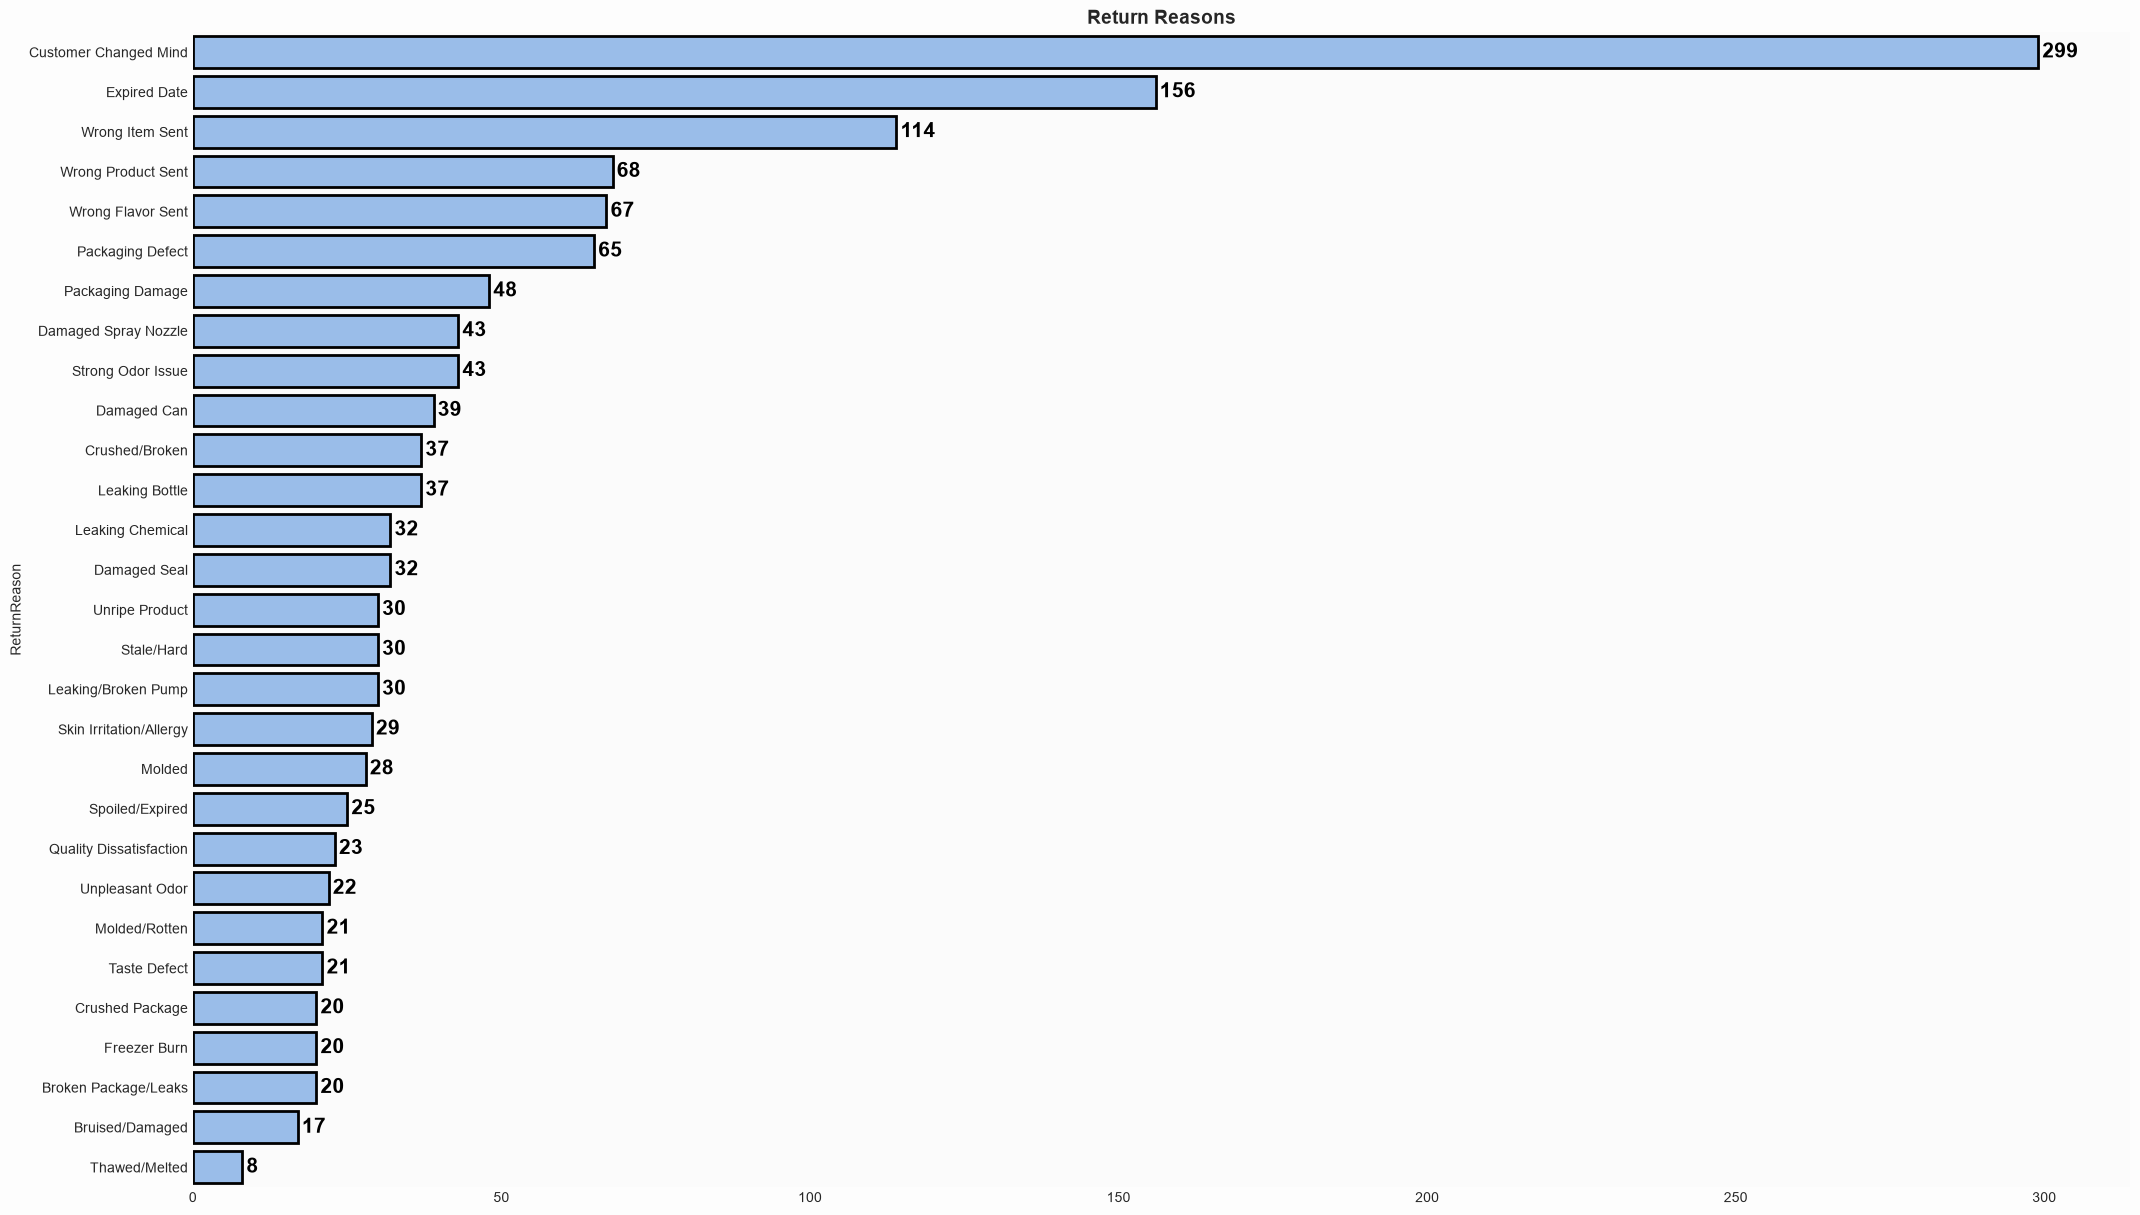

In [62]:
plt.style.use('seaborn-v0_8-dark')
order_ReturnReason = IsReturned['ReturnReason'].value_counts().index
fig , ax = plt.subplots(figsize=(25,15))
x = sns.countplot(data=IsReturned,y='ReturnReason',order=order_ReturnReason,color="#8DBCF6",linewidth=2,edgecolor='black')
for count in x.containers:
    x.bar_label(count,fmt='%.0f',padding=3,color='black',fontsize=15,fontweight='bold')
ax.set_title('Return Reasons',fontsize=14,fontweight="bold")
ax.set_xlabel('')
ax.set_facecolor("#FBFBFB")
fig.patch.set_facecolor("#FDFDFD")
plt.show()

In [63]:
print(IsReturned['TotalSales'].agg('sum'))

33478.0105


In [64]:
IsReturned

,ProductID,Quantity,UnitCost,UnitPrice,DiscountRate,IsReturned,ReturnDate,ReturnTime,ReturnReason,TotalCost,TotalSales,NetCost,NetSales,Profit,Years,Months,ReturnDay
OrderID,,,,,,,,,,,,,,,,,
ORD00012,PRDCT0029,18,1.35,2.11,0.00,1,2025-06-09,22:56:54,Molded/Rotten,24.30,37.980,0.0,0.0,0.0,2025,June,2 days
ORD00013,PRDCT0016,2,5.80,9.15,0.10,1,2025-06-08,08:11:28,Expired Date,11.60,16.470,0.0,0.0,0.0,2025,June,3 days
ORD00018,PRDCT0037,1,1.42,1.85,0.00,1,2023-03-20,09:21:35,Damaged Can,1.42,1.850,0.0,0.0,0.0,2023,March,3 days
ORD00022,PRDCT0016,3,4.79,7.56,0.15,1,2023-09-13,00:24:01,Wrong Item Sent,14.37,19.278,0.0,0.0,0.0,2023,September,2 days
ORD00024,PRDCT0006,1,11.10,13.99,0.00,1,2024-08-24,11:52:38,Spoiled/Expired,11.10,13.990,0.0,0.0,0.0,2024,August,1 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ORD09958,PRDCT0037,1,1.42,1.85,0.00,1,2023-05-27,12:42:47,Expired Date,1.42,1.850,0.0,0.0,0.0,2023,May,1 days
ORD09964,PRDCT0018,2,8.07,10.60,0.00,1,2023-07-01,05:28:41,Wrong Item Sent,16.14,21.200,0.0,0.0,0.0,2023,July,3 days
ORD09964,PRDCT0028,3,3.79,4.83,0.00,1,2023-06-30,11:28:41,Unripe Product,11.37,14.490,0.0,0.0,0.0,2023,June,2 days


<Axes: ylabel='Years'>

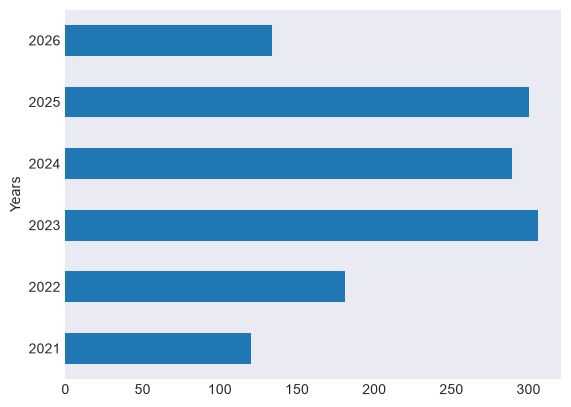

In [65]:
# how Year have a most Return Orders

Top_YearReturn = IsReturned.reset_index().groupby('Years')['OrderID'].nunique()
Top_YearReturn.plot(kind='barh')

# Why This Drop in 2026

In [66]:
year_2026 = order_details[order_details['Years'] == 2026]
year_2026

,ProductID,Quantity,UnitCost,UnitPrice,DiscountRate,IsReturned,ReturnDate,ReturnTime,ReturnReason,TotalCost,TotalSales,NetCost,NetSales,Profit,Years,Months
OrderID,,,,,,,,,,,,,,,,
ORD00008,PRDCT0087,3,9.50,14.74,0.15,0,9999-12-31,00:00:00,NaN,28.50,37.587,28.50,37.587,9.087,2026,April
ORD00008,PRDCT0076,1,15.49,23.92,0.00,0,9999-12-31,00:00:00,NaN,15.49,23.920,15.49,23.920,8.430,2026,April
ORD00011,PRDCT0075,1,4.36,6.67,0.00,0,9999-12-31,00:00:00,NaN,4.36,6.670,4.36,6.670,2.310,2026,March
ORD00011,PRDCT0079,1,14.41,19.17,0.00,0,9999-12-31,00:00:00,NaN,14.41,19.170,14.41,19.170,4.760,2026,March
ORD00011,PRDCT0085,3,4.04,5.62,0.10,0,9999-12-31,00:00:00,NaN,12.12,15.174,12.12,15.174,3.054,2026,March
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ORD09974,PRDCT0056,2,3.45,5.44,0.20,0,9999-12-31,00:00:00,NaN,6.90,8.704,6.90,8.704,1.804,2026,February
ORD09998,PRDCT0023,3,2.71,3.69,0.00,0,9999-12-31,00:00:00,NaN,8.13,11.070,8.13,11.070,2.940,2026,April
ORD09998,PRDCT0016,1,6.38,10.07,0.00,0,9999-12-31,00:00:00,NaN,6.38,10.070,6.38,10.070,3.690,2026,April


In [67]:
year_2026['Months'].unique()

<StringArray>
['April', 'March', 'May', 'February', 'January', 'June']
Length: 6, dtype: str

In [68]:
print('2026 Orders:',
      year_2026.reset_index()['OrderID'].nunique())

print('2026 Quantity:',
      year_2026['Quantity'].sum())

print('2026 Profit:',
      year_2026['Profit'].sum())

2026 Orders: 926
2026 Quantity: 7557
2026 Profit: 25689.0965


# Compare Profit and Quantity and Orders in 2025 , 2026


In [69]:
jan_to_june_2025 = order_details[
    (order_details['Years'] == 2025) &
    (
        (order_details['Months'] == 'January') |
        (order_details['Months'] == 'February') |
        (order_details['Months'] == 'March') |
        (order_details['Months'] == 'April') |
        (order_details['Months'] == 'May') |
        (order_details['Months'] == 'June')
    )
]

jan_to_june_2025

,ProductID,Quantity,UnitCost,UnitPrice,DiscountRate,IsReturned,ReturnDate,ReturnTime,ReturnReason,TotalCost,TotalSales,NetCost,NetSales,Profit,Years,Months
OrderID,,,,,,,,,,,,,,,,
ORD00012,PRDCT0003,2,12.84,20.35,0.0,0,9999-12-31,00:00:00,NaN,25.68,40.700,25.68,40.700,15.020,2025,June
ORD00012,PRDCT0029,18,1.35,2.11,0.0,1,2025-06-09,22:56:54,Molded/Rotten,24.30,37.980,0.00,0.000,0.000,2025,June
ORD00012,PRDCT0010,1,20.04,30.45,0.0,0,9999-12-31,00:00:00,NaN,20.04,30.450,20.04,30.450,10.410,2025,June
ORD00013,PRDCT0014,1,3.50,4.98,0.0,0,9999-12-31,00:00:00,NaN,3.50,4.980,3.50,4.980,1.480,2025,June
ORD00013,PRDCT0008,1,13.56,21.30,0.0,0,9999-12-31,00:00:00,NaN,13.56,21.300,13.56,21.300,7.740,2025,June
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ORD09984,PRDCT0090,3,13.09,20.85,0.0,1,2025-01-21,21:21:56,Strong Odor Issue,39.27,62.550,0.00,0.000,0.000,2025,January
ORD09986,PRDCT0023,3,2.46,3.35,0.0,0,9999-12-31,00:00:00,NaN,7.38,10.050,7.38,10.050,2.670,2025,January
ORD09986,PRDCT0004,1,12.96,16.76,0.1,0,9999-12-31,00:00:00,NaN,12.96,15.084,12.96,15.084,2.124,2025,January


In [70]:
print('2025\n')
print('2025 Orders:',
      jan_to_june_2025.reset_index()['OrderID'].nunique())
print('2025 Quantity:',
      jan_to_june_2025['Quantity'].sum())
print('2025 Profit:',
      jan_to_june_2025['Profit'].sum())
print('')
print('--'*50)
print('')

print('2026\n')
print('2026 Orders:',
      year_2026.reset_index()['OrderID'].nunique())
print('2026 Quantity:',
      year_2026['Quantity'].sum())
print('2026 Profit:',
      year_2026['Profit'].sum())

2025

2025 Orders: 1102
2025 Quantity: 8572
2025 Profit: 25241.137499999997

----------------------------------------------------------------------------------------------------

2026

2026 Orders: 926
2026 Quantity: 7557
2026 Profit: 25689.0965


In [71]:
jan_to_june_2025.pivot_table(index=['Years','Months'],values=['Quantity','Profit'] ,aggfunc='sum')

Profit  Quantity
Years Months                       
2025  April     3549.8735      1127
      February  3592.1820      1304
      January   3787.8500      1346
      June      4829.9160      1647
      March     4373.9570      1399
      May       5107.3590      1749

In [72]:
year_2026.pivot_table(index=['Years','Months'],values=['Quantity','Profit'] ,aggfunc='sum')

Profit  Quantity
Years Months                       
2026  April     5405.4875      1532
      February  3084.2930      1124
      January   5151.7585      1608
      June       330.7565        98
      March     5932.0490      1543
      May       5784.7520      1652

In [73]:
# with pd.ExcelWriter('Retail_Project.xlsx') as W:
    
#     Categories.to_excel(W, sheet_name='Categories')
#     products.to_excel(W, sheet_name='Products')
#     customers.to_excel(W, sheet_name='Customers')
#     orders.to_excel(W, sheet_name='Orders')
#     order_details.to_excel(W, sheet_name='Order_Details')
#     IsReturned.to_excel(W, sheet_name='IsReturned')

# Final Business Insights & Recommendations

Overall Business Performance

From 2021 to 2025, the business showed a consistent positive growth trend. Total sales increased year after year, rising from approximately $50.52K in 2021 to $184.46K in 2025. Profit followed the same trend, growing from around $13.56K to $48.59K, which indicates continuous improvement in the company’s financial performance.

The number of orders also increased significantly during the early years and later stabilized at around 2.2K orders per year. Despite this stabilization, sales and profit continued to grow, suggesting that the business was generating more value from its transactions and product mix.

2026 Performance

At first glance, 2026 appears to show a decline compared with previous years. However, further analysis shows that 2026 contains incomplete-year data, with only the first months of the year available.

When comparing the same available period with 2025, 2026 actually shows stronger performance. Profit and sales during the comparable months are higher, suggesting that 2026 is performing well and could potentially outperform 2025 if the current trend continues.

Therefore, the apparent annual drop in 2026 should not be interpreted as a decline in business performance.

Financial Summary

Across the entire analyzed period, the business generated approximately $761.95K in total sales. After accounting for $33.48K in returned sales, net sales reached approximately $728.47K.

With a net cost of $526.27K, the company generated a total profit of approximately $202.20K, showing that the business remained strongly profitable throughout the analyzed period.

Returns Performance

Product returns have a noticeable but controlled impact on the business. The most common return reason is Customer Changed Mind, indicating that a significant portion of returns may be related to customer expectations rather than product defects.

Improving product descriptions, product information, and the customer purchasing experience could help customers make better purchase decisions and potentially reduce unnecessary returns.

Final Conclusion

Overall, the analysis shows a healthy and growing business. Sales and profit improved consistently between 2021 and 2025, while the available 2026 data indicates that the positive trend is continuing.

The business should focus on maintaining its sales and profitability growth while reducing avoidable product returns, particularly those caused by customers changing their purchase decisions